In [3]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point
from geopy.distance import geodesic
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.linear_model import LinearRegression, Ridge, BayesianRidge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import make_pipeline

from libpysal.weights import KNN
from spreg import ML_Lag


c:\Users\bhara\Desktop\Github Works\House Price Prediction\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# Load dataset
file_path = r"C:\Users\bhara\Desktop\Github Works\House Price Prediction\Bengaluru_House_Data_with_coords.csv"
df = pd.read_csv(file_path)
df.info()
df.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
 9   latitude      13320 non-null  float64
 10  longitude     13320 non-null  float64
dtypes: float64(5), object(6)
memory usage: 1.1+ MB


,area_type,availability,location,size,society,total_sqft,bath,balcony,price,latitude,longitude
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07,12.844149,77.679381
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00,12.896745,77.866742
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00,12.906982,77.552059
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00,12.874358,77.513787
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00,13.055193,77.642221
5,Super built-up Area,Ready To Move,Whitefield,2 BHK,DuenaTa,1170,2.0,1.0,38.00,12.969820,77.749972
6,Super built-up Area,18-May,Old Airport Road,4 BHK,Jaades,2732,4.0,NaN,204.00,12.954733,77.683761
7,Super built-up Area,Ready To Move,Rajaji Nagar,4 BHK,Brway G,3300,4.0,NaN,600.00,12.998173,77.553045
8,Super built-up Area,Ready To Move,Marathahalli,3 BHK,NaN,1310,3.0,1.0,63.25,12.956924,77.701127
9,Plot Area,Ready To Move,Gandhi Bazar,6 Bedroom,NaN,1020,6.0,NaN,370.00,12.945589,77.571256


In [6]:
def convert_sqft(sqft):
    try:
        # Handle numeric input directly
        if isinstance(sqft, (int, float)):
            return float(sqft)

        # Clean string input
        sqft = sqft.lower().replace('sq. meter', '').replace('acres', '').strip()

        if '-' in sqft:
            parts = list(map(float, sqft.split('-')))
            return sum(parts) / 2
        return float(sqft)
    except:
        return None



In [7]:
# Drop duplicates
df = df.drop_duplicates()

# Remove rows missing key fields
df = df.dropna(subset=['latitude', 'longitude', 'price', 'total_sqft', 'size'])

# Fill missing bath/balcony with median
df['bath'] = df['bath'].fillna(df['bath'].median())
df['balcony'] = df['balcony'].fillna(df['balcony'].median())

# Convert total_sqft to numeric
df['total_sqft'] = df['total_sqft'].apply(convert_sqft)
df = df.dropna(subset=['total_sqft'])


# Handle size column safely
df['Bedroom'] = df["size"].apply(lambda x: int(x.split(" ")[0]))




In [8]:
print(df.columns)

Index(['area_type', 'availability', 'location', 'size', 'society',
       'total_sqft', 'bath', 'balcony', 'price', 'latitude', 'longitude',
       'Bedroom'],
      dtype='object')


In [9]:
# Convert DataFrame to GeoDataFrame for spatial analysis
df['geometry'] = [Point(xy) for xy in zip(df["longitude"], df["latitude"])]
geo_df = gpd.GeoDataFrame(df, geometry='geometry')


In [10]:
# Compute distance to central locations
important_places = {
    "Electronic City": (12.8452, 77.6600),
    "Whitefield": (12.9698, 77.7500),
    "MG Road": (12.9740, 77.6060),
    "Airport": (13.1986, 77.7066)
}
for place, coords in important_places.items():
    df[f'distance_to_{place.replace(" ", "_").lower()}'] = df.apply(
        lambda row: geodesic((row['latitude'], row['longitude']), coords).km, axis=1
    )





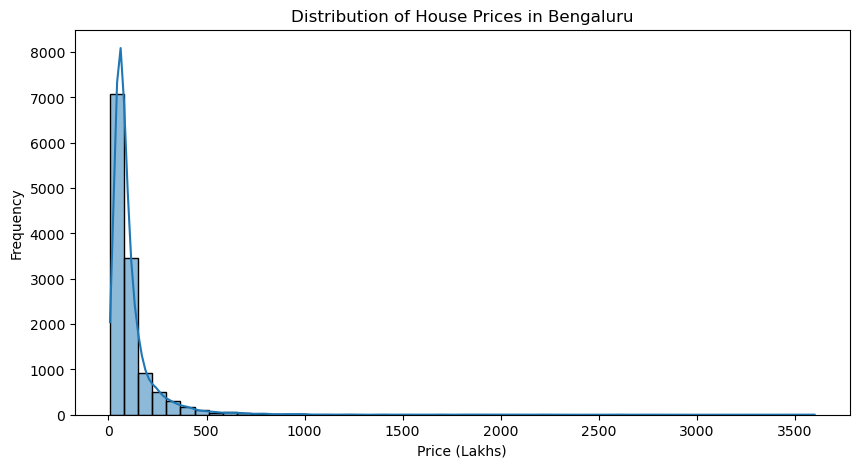

In [19]:
# Plot Price Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df["price"], bins=50, kde=True)
plt.title("Distribution of House Prices in Bengaluru")
plt.xlabel("Price (Lakhs)")
plt.ylabel("Frequency")
plt.show()

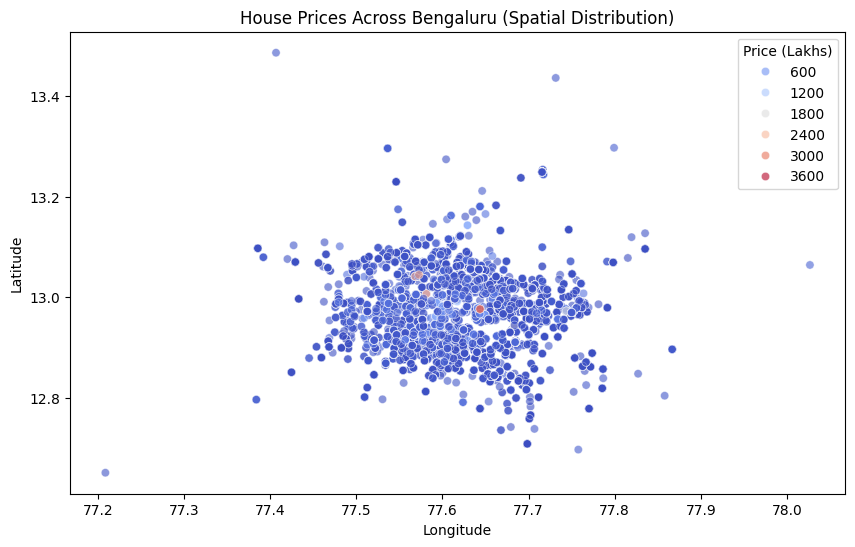

In [11]:
# Scatter plot of house prices by location
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df["longitude"], y=df["latitude"], hue=df["price"], palette="coolwarm", alpha=0.6)
plt.title("House Prices Across Bengaluru (Spatial Distribution)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Price (Lakhs)", loc='upper right')
plt.show()


In [12]:
# Price summary by location
price_summary = df.groupby("location")["price"].agg(["count", "mean", "median", "std"]).sort_values(by="count", ascending=False)
print(price_summary.head())

                 count        mean  median         std
location                                              
Whitefield         520  129.254798   75.50  142.483262
Sarjapur  Road     377  121.391074   85.00  117.169538
Electronic City    287   55.706760   47.00   47.773060
Kanakpura Road     249   71.848655   64.39   36.512007
Thanisandra        229   83.330044   74.75   43.197070


In [13]:
#  Remove outliers
df = df[df['price'] < df['price'].quantile(0.99)]
df = df[df['total_sqft'] < df['total_sqft'].quantile(0.99)]

In [14]:
df[df.bath>10]

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,latitude,longitude,Bedroom,geometry,distance_to_electronic_city,distance_to_whitefield,distance_to_mg_road,distance_to_airport
938,Plot Area,Ready To Move,5th Phase JP Nagar,9 Bedroom,NaN,1260.0,11.0,2.0,290.0,12.900137,77.588352,9,POINT (77.58835189999999 12.9001371),9.869880,19.159286,8.392850,35.422648
1078,Plot Area,Ready To Move,BTM 1st Stage,9 Bedroom,Srvasks,3300.0,14.0,2.0,500.0,12.919941,77.610651,9,POINT (77.61065119999999 12.9199409),9.851734,16.095227,6.001818,32.537382
1768,Plot Area,Ready To Move,1 Ramamurthy Nagar,11 Bedroom,NaN,1200.0,11.0,0.0,170.0,13.029419,77.682401,11,POINT (77.6824007 13.0294187),20.524552,9.863206,10.309428,18.899822
1953,Plot Area,Ready To Move,KR Puram,8 Bedroom,NaN,1200.0,12.0,2.0,110.0,13.016999,77.704433,8,POINT (77.7044335 13.0169992),19.608201,7.190482,11.690357,20.092126
1979,Plot Area,Ready To Move,Hongasandra,8 Bedroom,NaN,990.0,12.0,0.0,120.0,12.893362,77.625808,8,POINT (77.6258081 12.8933622),6.493263,15.909999,9.176248,34.887220
3379,Super built-up Area,Ready To Move,1Hanuman Nagar,19 BHK,NaN,2000.0,16.0,2.0,490.0,12.879989,77.607957,19,POINT (77.6079575 12.879989),6.835388,18.338840,10.402593,36.836325
4684,Plot Area,Ready To Move,Munnekollal,43 Bedroom,NaN,2400.0,40.0,0.0,660.0,12.953019,77.708811,43,POINT (77.7088108 12.9530189),13.051374,4.839353,11.393965,27.169974
4916,Super built-up Area,Ready To Move,1Channasandra,14 BHK,NaN,1250.0,15.0,0.0,125.0,12.979774,77.769682,14,POINT (77.7696819 12.979774),19.061212,2.403641,17.770117,25.156991
8106,Plot Area,Ready To Move,Wilson Garden,8 Bedroom,NaN,1850.0,12.0,2.0,300.0,12.948193,77.597186,8,POINT (77.59718649999999 12.9481933),13.277754,16.752069,3.010895,30.137186
8636,Super built-up Area,Ready To Move,Neeladri Nagar,10 BHK,NaN,4000.0,12.0,2.0,160.0,12.839094,77.647169,10,POINT (77.6471693 12.8390936),1.547993,18.265630,15.579072,40.291531


In [15]:
df = df.copy()
df["price_per_sqft"] = df["price"]*100000/df["total_sqft"]
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,latitude,longitude,Bedroom,geometry,distance_to_electronic_city,distance_to_whitefield,distance_to_mg_road,distance_to_airport,price_per_sqft
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056.0,2.0,1.0,39.07,12.844149,77.679381,2,POINT (77.6793813 12.8441489),2.107087,15.873435,16.425102,39.324162,3699.810606
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600.0,5.0,3.0,120.00,12.896745,77.866742,4,POINT (77.86674160000001 12.8967455),23.153063,15.026597,29.556450,37.641604,4615.384615
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440.0,2.0,3.0,62.00,12.906982,77.552059,3,POINT (77.552059 12.9069823),13.563733,22.575150,9.446133,36.356426,4305.555556
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521.0,3.0,1.0,95.00,12.874358,77.513787,3,POINT (77.513787 12.8743581),16.195239,27.722945,14.887891,41.522784,6245.890861
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200.0,2.0,1.0,51.00,13.055193,77.642221,2,POINT (77.6422206 13.0551932),23.311524,15.031524,9.804219,17.333129,4250.000000


In [16]:
df = df[df["bath"] <= 10]
df = df[~(df.total_sqft/df.Bedroom<300)]

In [17]:
def remove_pps_outliers(df):
    df_out = pd.DataFrame()
    for key, subdf in df.groupby('location'):
        m = np.mean(subdf.price_per_sqft)
        st = np.std(subdf.price_per_sqft)
        reduced_df = subdf[(subdf.price_per_sqft>(m-st)) & (subdf.price_per_sqft<=(m+st))]
        df_out = pd.concat([df_out,reduced_df],ignore_index=True)
    return df_out
df = remove_pps_outliers(df)
df.shape

(8453, 18)

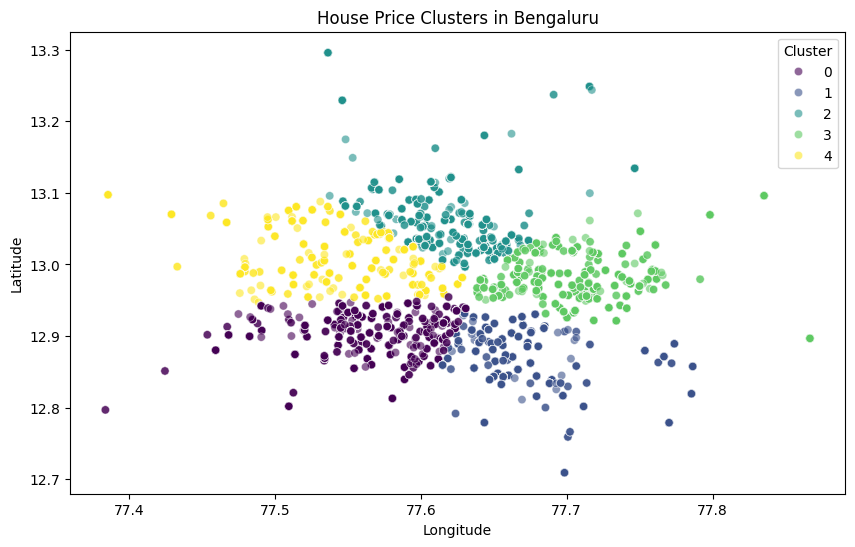

In [18]:
# Clustering
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(df[['latitude', 'longitude']])

# Cluster-based summary statistics
cluster_summary = df.groupby("cluster")["price"].agg(["count", "mean", "median", "std"]).sort_values(by="mean", ascending=False)
cluster_summary

# Plot clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df["longitude"], y=df["latitude"], hue=df["cluster"], palette="viridis", alpha=0.6)
plt.title("House Price Clusters in Bengaluru")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Cluster")
plt.show()

In [19]:
check_cols = [
    "Bedroom", "total_sqft", "bath", "balcony",
    "distance_to_electronic_city", "distance_to_whitefield",
    "distance_to_mg_road", "distance_to_airport",
    "price", "cluster"
]

missing_counts = df[check_cols].isna().sum()
print("🔍 Missing values in key columns:\n", missing_counts)


🔍 Missing values in key columns:
 Bedroom                        0
total_sqft                     0
bath                           0
balcony                        0
distance_to_electronic_city    0
distance_to_whitefield         0
distance_to_mg_road            0
distance_to_airport            0
price                          0
cluster                        0
dtype: int64


C:\Users\bhara\AppData\Local\Temp\ipykernel_15096\2606182037.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_summary.index, y=cluster_summary["mean"], palette="viridis")


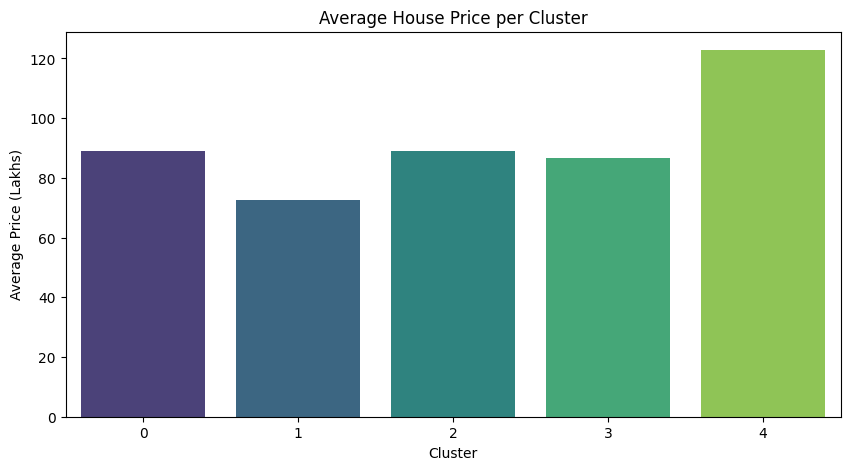

C:\Users\bhara\AppData\Local\Temp\ipykernel_15096\2606182037.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df["cluster"], y=df["price"], palette="coolwarm")


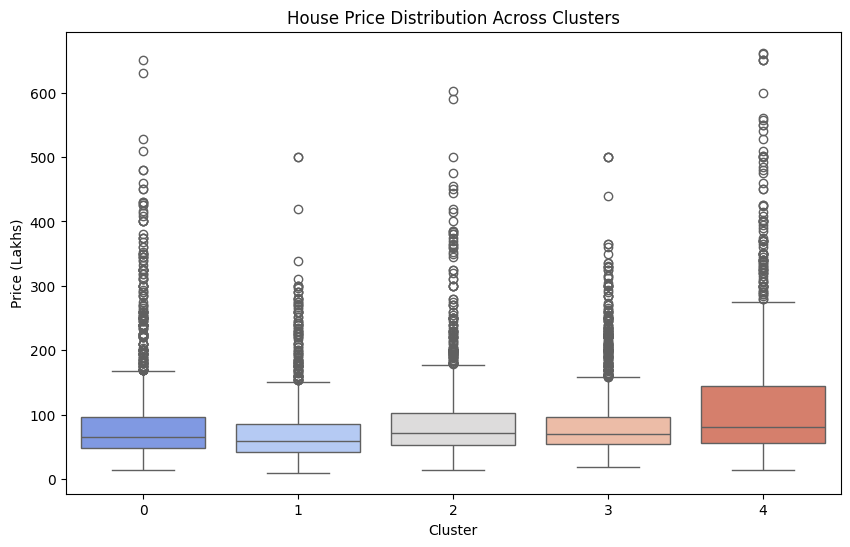

In [20]:
# Plot average price per cluster
plt.figure(figsize=(10, 5))
sns.barplot(x=cluster_summary.index, y=cluster_summary["mean"], palette="viridis")
plt.title("Average House Price per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Price (Lakhs)")
plt.show()

# Plot price variation across clusters
plt.figure(figsize=(10, 6))
sns.boxplot(x=df["cluster"], y=df["price"], palette="coolwarm")
plt.title("House Price Distribution Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Price (Lakhs)")
plt.show()

C:\Users\bhara\AppData\Local\Temp\ipykernel_15096\343693480.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df["cluster"], y=df["bath"], palette="coolwarm")


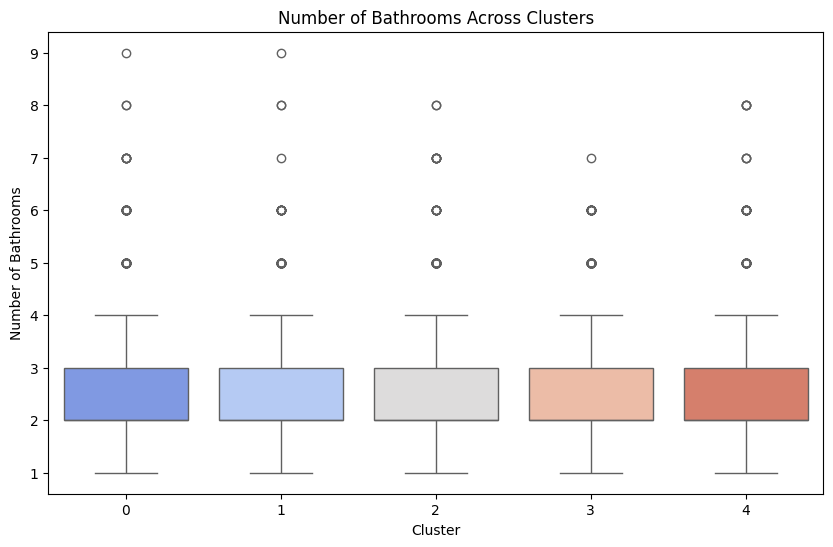

C:\Users\bhara\AppData\Local\Temp\ipykernel_15096\343693480.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df["cluster"], y=df["distance_to_electronic_city"], palette="coolwarm")


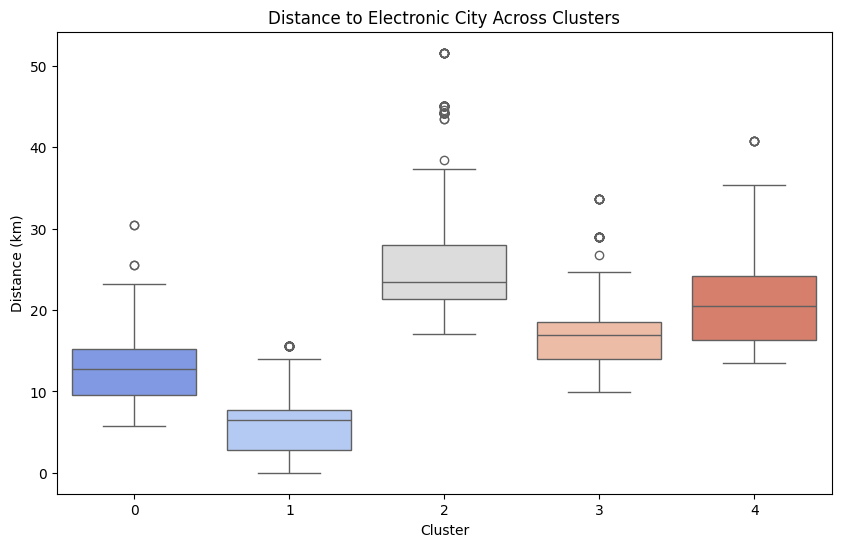

C:\Users\bhara\AppData\Local\Temp\ipykernel_15096\343693480.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df["cluster"], y=df["distance_to_mg_road"], palette="coolwarm")


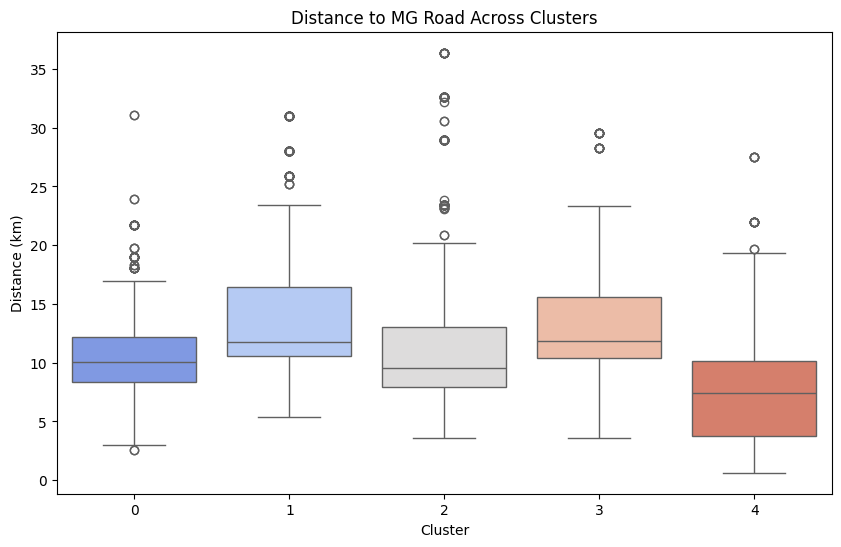

In [21]:
# Plot distribution of number of bathrooms across clusters
plt.figure(figsize=(10, 6))
sns.boxplot(x=df["cluster"], y=df["bath"], palette="coolwarm")
plt.title("Number of Bathrooms Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Number of Bathrooms")
plt.show()

# Plot distribution of distance to Electronic City across clusters
plt.figure(figsize=(10, 6))
sns.boxplot(x=df["cluster"], y=df["distance_to_electronic_city"], palette="coolwarm")
plt.title("Distance to Electronic City Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Distance (km)")
plt.show()

# Plot distribution of distance to MG Road across clusters
plt.figure(figsize=(10, 6))
sns.boxplot(x=df["cluster"], y=df["distance_to_mg_road"], palette="coolwarm")
plt.title("Distance to MG Road Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Distance (km)")
plt.show()

In [22]:
# Prepare data
features = [
    "Bedroom", "total_sqft", "bath", "balcony",
    "distance_to_electronic_city", "distance_to_whitefield",
    "distance_to_mg_road", "distance_to_airport"
]
df_model = df[features + ["price", "cluster"]].dropna()

X = df_model[features]
y = df_model["price"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_cluster = df_model[features + ["cluster"]]
X_train_cluster, X_test_cluster, y_train_cluster, y_test_cluster = train_test_split(
    X_cluster, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_cluster_scaled = scaler.fit_transform(X_train_cluster)
X_test_cluster_scaled = scaler.transform(X_test_cluster)


In [23]:
# Evaluation function
def train_and_evaluate(model, X_train, X_test, y_train, y_test, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    return pd.DataFrame([[model_name, mae, rmse, r2]], 
                        columns=["Model", "MAE", "RMSE", "R2 Score"])


In [24]:
# Define models
models = [
    (RandomForestRegressor(n_estimators=100, random_state=42), "Random Forest (No Clustering)"),
    (xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42), "XGBoost (No Clustering)"),
    (LinearRegression(), "Linear Regression (No Clustering)"),
    (Ridge(alpha=1.0), "Ridge Regression (No Clustering)"),
    (make_pipeline(PolynomialFeatures(degree=2), Ridge(alpha=1.0)), "Polynomial Ridge (No Clustering)"),
    
]

models_cluster = [
    (RandomForestRegressor(n_estimators=100, random_state=42), "Random Forest (With Clustering)"),
    (xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42), "XGBoost (With Clustering)"),
    (LinearRegression(), "Linear Regression (With Clustering)"),
    (Ridge(alpha=1.0), "Ridge Regression (With Clustering)"),
    (make_pipeline(PolynomialFeatures(degree=2), Ridge(alpha=1.0)), "Polynomial Ridge (With Clustering)"),
   
]


In [25]:
results = pd.concat([train_and_evaluate(m, X_train_scaled, X_test_scaled, y_train, y_test, name)
                     for m, name in models], ignore_index=True)
results_cluster = pd.concat([train_and_evaluate(m, X_train_cluster_scaled, X_test_cluster_scaled, y_train_cluster, y_test_cluster, name)
                             for m, name in models_cluster], ignore_index=True)

final_results = pd.concat([results, results_cluster], ignore_index=True)
final_results

,Model,MAE,RMSE,R2 Score
0,Random Forest (No Clustering),14.001039,27.140794,0.855577
1,XGBoost (No Clustering),14.428823,26.394951,0.863406
2,Linear Regression (No Clustering),22.978996,39.946472,0.687142
3,Ridge Regression (No Clustering),22.978726,39.947655,0.687124
4,Polynomial Ridge (No Clustering),20.939016,35.347079,0.755039
5,Random Forest (With Clustering),13.934373,27.017359,0.856888
6,XGBoost (With Clustering),14.380303,26.498465,0.862332
7,Linear Regression (With Clustering),22.936044,39.736819,0.690417
8,Ridge Regression (With Clustering),22.935926,39.738001,0.690399
9,Polynomial Ridge (With Clustering),20.859860,34.884817,0.761404


C:\Users\bhara\AppData\Local\Temp\ipykernel_15096\3770250571.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Value", y="Model", data=subset, palette="viridis")


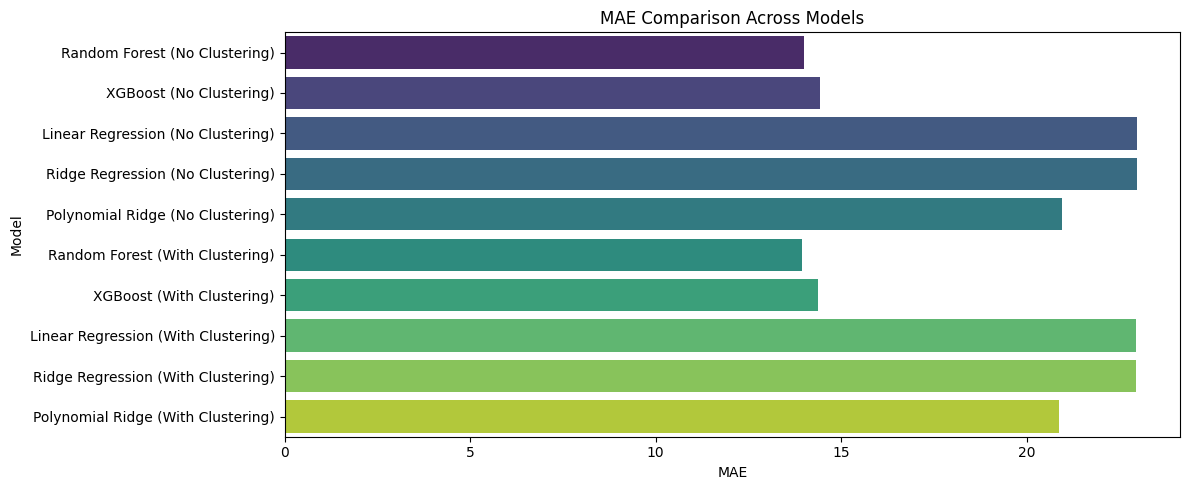

C:\Users\bhara\AppData\Local\Temp\ipykernel_15096\3770250571.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Value", y="Model", data=subset, palette="viridis")


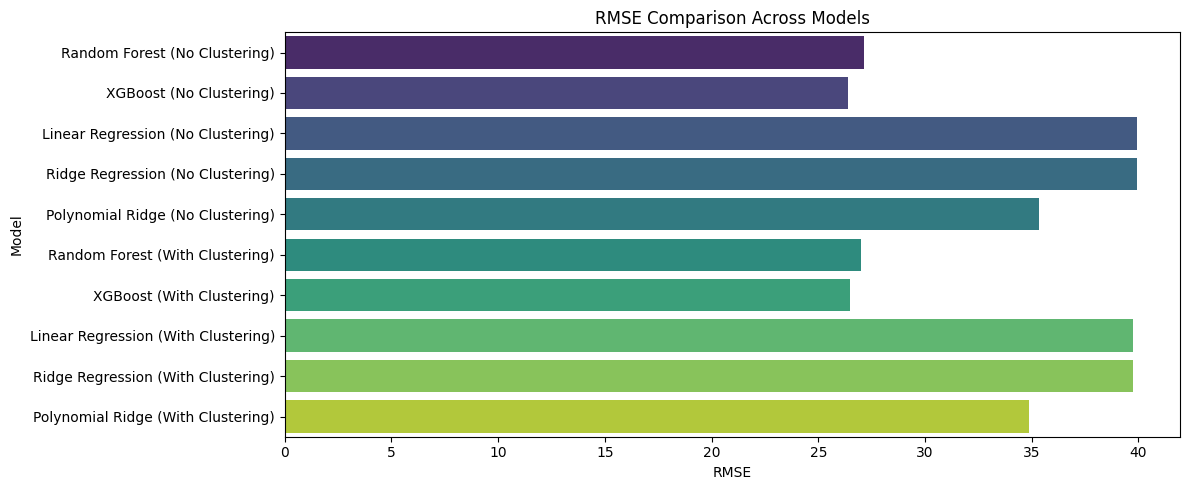

C:\Users\bhara\AppData\Local\Temp\ipykernel_15096\3770250571.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Value", y="Model", data=subset, palette="viridis")


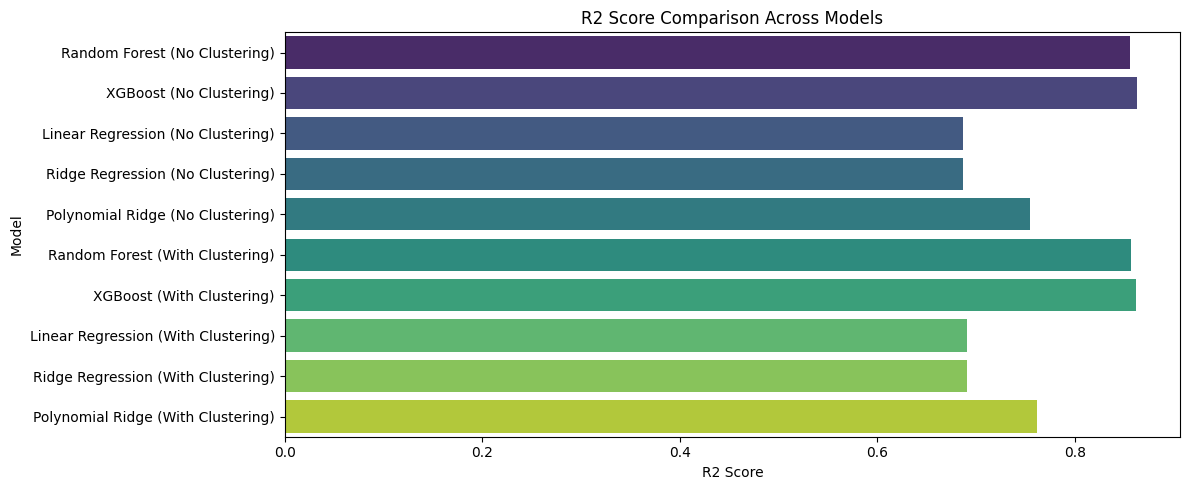

In [26]:
# Prepare data for plotting
melted_results = final_results.melt(id_vars='Model', var_name='Metric', value_name='Value')

# Plot each metric separately
metrics = ['MAE', 'RMSE', 'R2 Score']
for metric in metrics:
    plt.figure(figsize=(12, 5))
    subset = melted_results[melted_results['Metric'] == metric]
    sns.barplot(x="Value", y="Model", data=subset, palette="viridis")
    plt.title(f"{metric} Comparison Across Models")
    plt.xlabel(metric)
    plt.ylabel("Model")
    plt.tight_layout()
    plt.show()


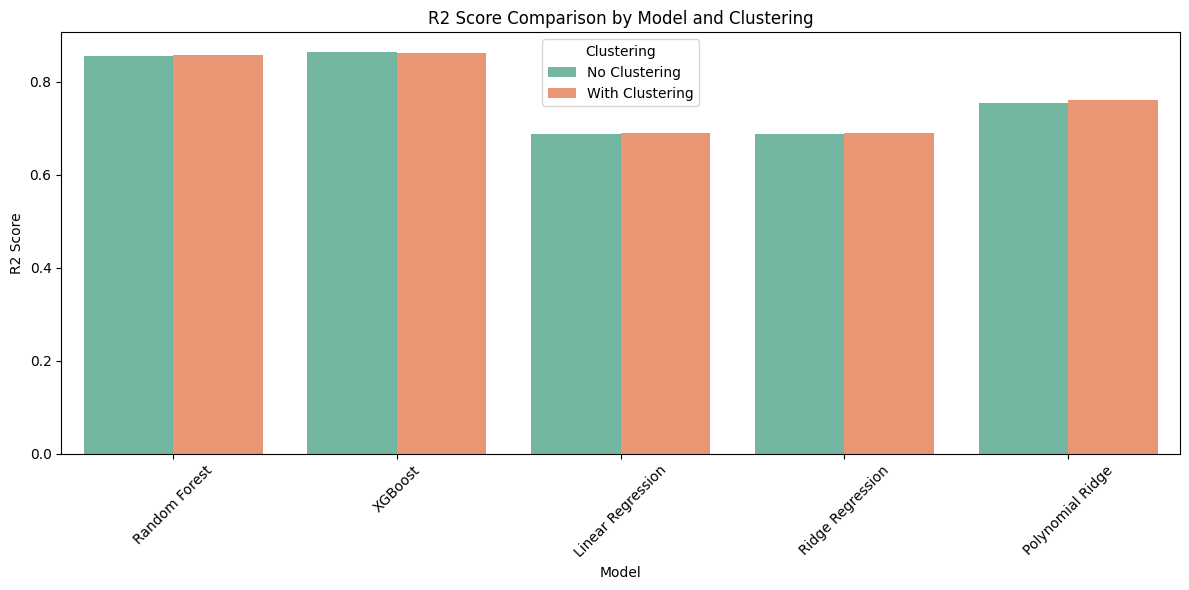

In [27]:
# Prepare grouped bar chart data
# Extract model base names and clustering type
final_results["Model Type"] = final_results["Model"].apply(lambda x: x.split("(")[0].strip())
final_results["Clustering"] = final_results["Model"].apply(lambda x: "With Clustering" if "With" in x else "No Clustering")

# Focus on one metric at a time (e.g., R2 Score)
metric = "R2 Score"

plt.figure(figsize=(12, 6))
sns.barplot(
    data=final_results,
    x="Model Type",
    y=metric,
    hue="Clustering",
    palette="Set2"
)
plt.title(f"{metric} Comparison by Model and Clustering")
plt.ylabel(metric)
plt.xlabel("Model")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


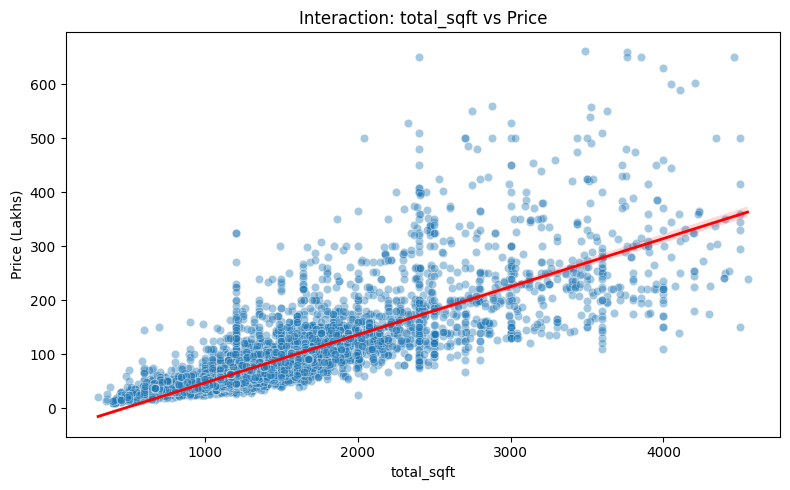

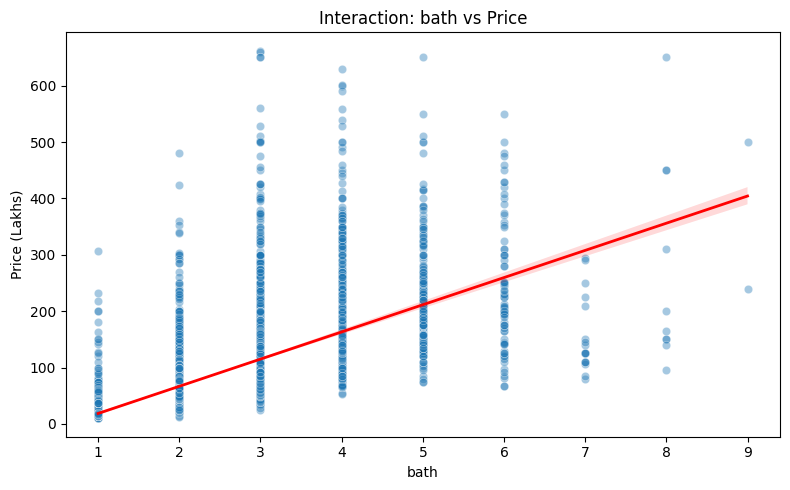

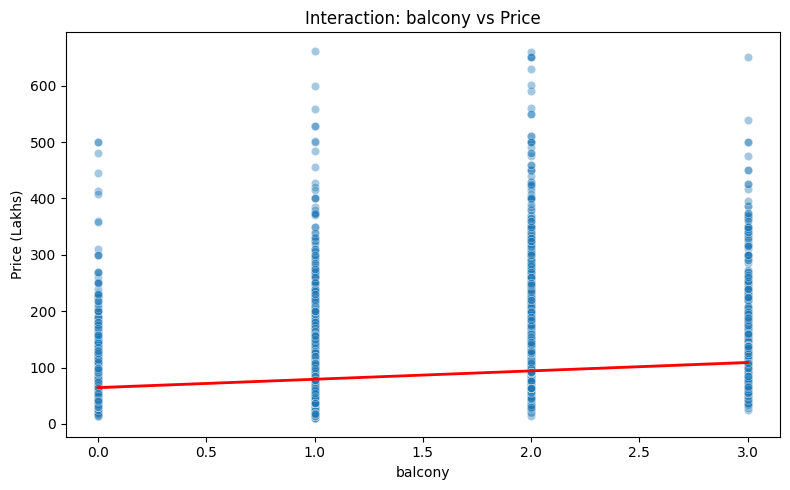

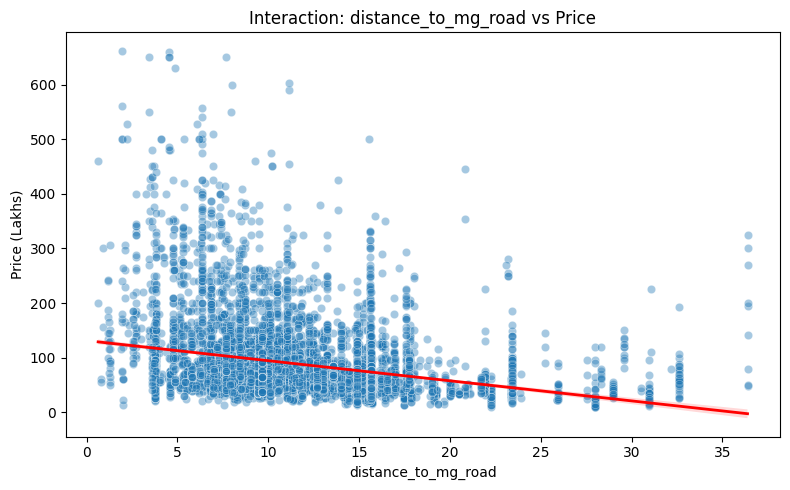

In [28]:
# Plot interactions
interaction_features = ["total_sqft", "bath", "balcony", "distance_to_mg_road"]

for feature in interaction_features:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df, x=feature, y="price", alpha=0.4)
    sns.regplot(data=df, x=feature, y="price", scatter=False, color="red", line_kws={"linewidth":2})
    plt.title(f"Interaction: {feature} vs Price")
    plt.xlabel(feature)
    plt.ylabel("Price (Lakhs)")
    plt.tight_layout()
    plt.show()

In [29]:
#Train XGBoost model ---
model = xgb.XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.1,
                         subsample=1.0, colsample_bytree=1.0,
                         random_state=42, verbosity=0)
model.fit(X_train_scaled, y_train)

# --- SHAP values and summary plot ---
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_scaled)

X_test_df = pd.DataFrame(X_test_scaled, columns=features)
shap.summary_plot(shap_values, features=X_test_df, feature_names=features)


ValueError: could not convert string to float: '[8.821543E1]'

In [ ]:

# Random Forest tuning
rf_params = {
    'n_estimators': [100, 150],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
rf = RandomForestRegressor(random_state=42)
rf_search = RandomizedSearchCV(rf, rf_params, n_iter=5, cv=3, scoring='r2', n_jobs=-1, random_state=42)
rf_search.fit(X_train_scaled, y_train)

# XGBoost tuning
xgb_params = {
    'n_estimators': [50, 100],
    'max_depth': [3, 6],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}
xgb_model = xgb.XGBRegressor(random_state=42, verbosity=0)
xgb_search = RandomizedSearchCV(xgb_model, xgb_params, n_iter=5, cv=3, scoring='r2', n_jobs=-1, random_state=42)
xgb_search.fit(X_train_scaled, y_train)

# Evaluate
def evaluate(model, name):
    y_pred = model.predict(X_test_scaled)
    return {
        "Model": name,
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R2 Score": r2_score(y_test, y_pred)
    }

results = [
    evaluate(rf_search.best_estimator_, "Tuned Random Forest"),
    evaluate(xgb_search.best_estimator_, "Tuned XGBoost")
]

results_df = pd.DataFrame(results)
print(results_df)

                 Model        MAE       RMSE  R2 Score
0  Tuned Random Forest  14.878496  29.239615  0.821322
1        Tuned XGBoost  15.603534  28.783875  0.826849


In [ ]:

final_xgb = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=1.0,
    colsample_bytree=1.0,
    random_state=42,
    verbosity=0
)
final_xgb.fit(X_train_cluster_scaled, y_train_cluster)

# Predict using the correct model
y_pred_xgb = final_xgb.predict(X_test_cluster_scaled)

# Evaluate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test_cluster, y_pred_xgb)
rmse = np.sqrt(mean_squared_error(y_test_cluster, y_pred_xgb))
r2 = r2_score(y_test_cluster, y_pred_xgb)

print(f" Final MAE: {mae:.2f}")
print(f" Final RMSE: {rmse:.2f}")
print(f" Final R²: {r2:.4f}")



 Final MAE: 15.28
 Final RMSE: 28.56
 Final R²: 0.8295


In [ ]:
# Create GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.longitude, df.latitude))
gdf.crs = "EPSG:4326"


In [ ]:

# Spatial weights (10 nearest neighbors)
w = KNN.from_dataframe(gdf, k=10)
w.transform = 'r'

# Define dependent and independent variables
y = gdf["price"].values.reshape(-1, 1)
X = gdf[["total_sqft", "bath", "balcony", "Bedroom"]].values

# Fit spatial lag model
model = ML_Lag(y, X, w=w, name_y="price", name_x=["sqft", "bath", "balcony", "Bedroom"])

#  View summary
print(model.summary)

/opt/anaconda3/lib/python3.12/site-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 109 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL LAG (METHOD = FULL)
-----------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :       price                Number of Observations:        8455
Mean dependent var  :     88.3259                Number of Variables   :           6
S.D. dependent var  :     68.4478                Degrees of Freedom    :        8449
Pseudo R-squared    :      0.7799
Spatial Pseudo R-squared:  0.6601
Log likelihood      : -41395.0284
Sigma-square ML     :   1031.1257                Akaike info criterion :   82802.057
S.E of regression   :     32.1111                Schwarz criterion     :   82844.312

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
---------------------------------------------------------------

In [ ]:
import joblib

#  Save the correct tuned XGBoost model with clustering
joblib.dump(final_xgb, "xgb_model.pkl")

# Save the StandardScaler used for training
joblib.dump(scaler, "scaler.pkl")

# Save the KMeans object used for adding 'cluster' feature
joblib.dump(kmeans, "kmeans.pkl")

print("All model components saved successfully.")


All model components saved successfully.


In [ ]:
import joblib

# Load the model
best_xgb_loaded = joblib.load("xgb_model.pkl")

# Predict using test data that includes cluster
y_pred = best_xgb_loaded.predict(X_test_cluster_scaled)



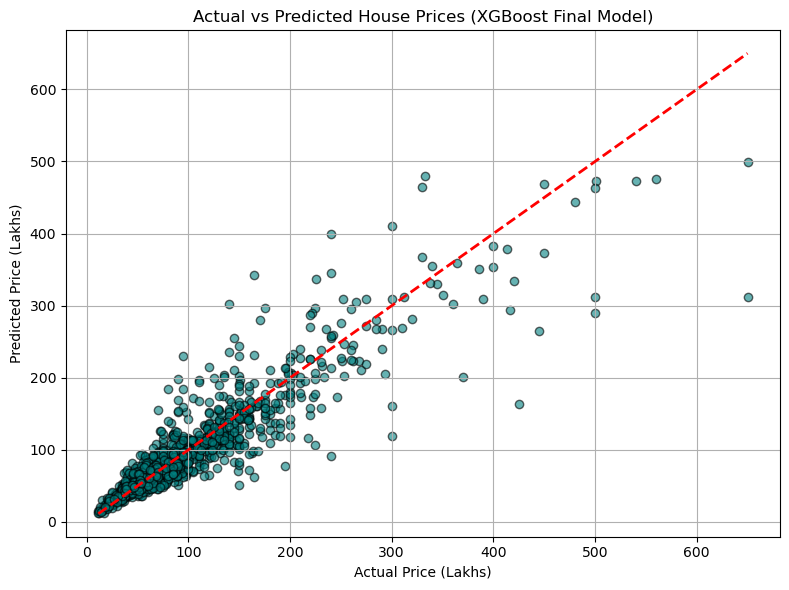

In [ ]:
# Predict using your final loaded model
y_test = y_test_cluster
y_pred = best_xgb_loaded.predict(X_test_cluster_scaled)

# Plot actual vs predicted
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color="teal", edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', lw=2)
plt.xlabel("Actual Price (Lakhs)")
plt.ylabel("Predicted Price (Lakhs)")
plt.title("Actual vs Predicted House Prices (XGBoost Final Model)")
plt.grid(True)
plt.tight_layout()
plt.show()


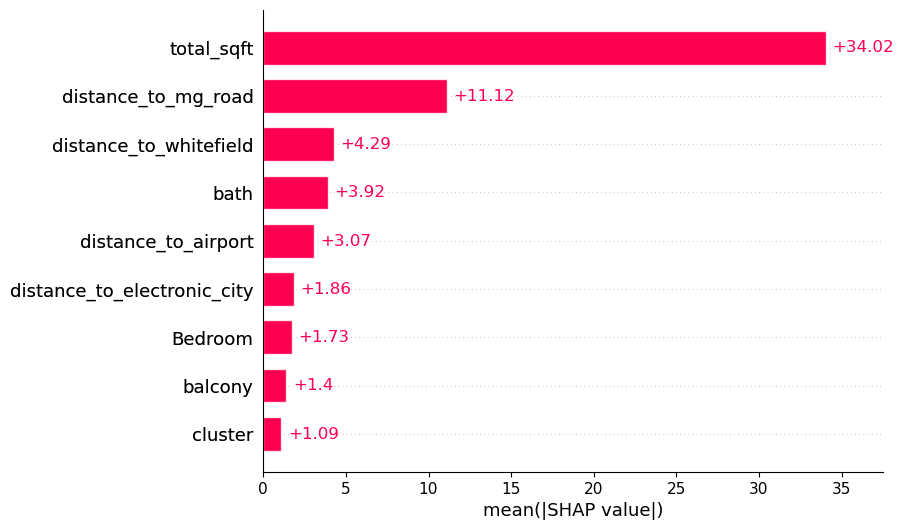

In [ ]:
X_test_df = pd.DataFrame(X_test_cluster_scaled, columns=[
    "Bedroom", "total_sqft", "bath", "balcony",
    "distance_to_electronic_city", "distance_to_whitefield",
    "distance_to_mg_road", "distance_to_airport", "cluster"
])


explainer = shap.Explainer(final_xgb)
shap_values = explainer(X_test_df)
shap.plots.bar(shap_values, max_display=10)

